<a href="https://colab.research.google.com/github/iam-mukeshvenkatesh/Machine-Learning-Concepts/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Diagnostic Classification using K-Nearest Neighbors

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Setting aesthetic style for plots
sns.set_theme(style="whitegrid")
plt.style.use('ggplot')

## 1. Data Loading and Cleaning

In [2]:
# Load dataset
data = pd.read_csv("breast-cancer.csv")

# Remove unnecessary columns if they exist
cols_to_drop = ['id']
data = data.drop(columns=[c for c in cols_to_drop if c in data.columns])

# Encode Target Variable (M=1, B=0)
le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])

print(f"Data Shape: {data.shape}")
data.head()

Data Shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Exploratory Data Analysis (EDA)

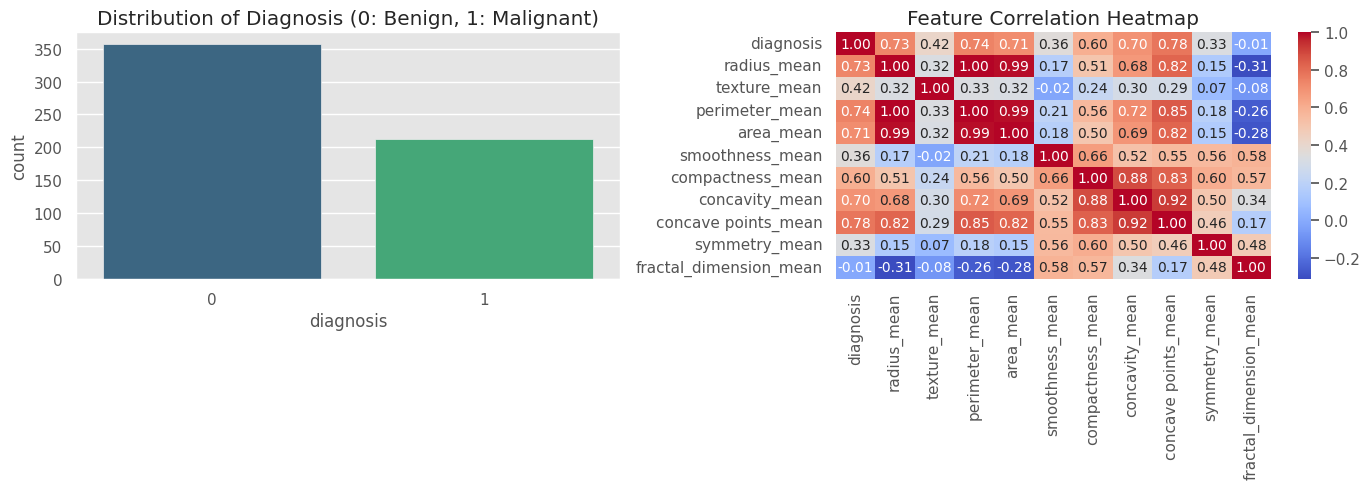

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Class Distribution
sns.countplot(x='diagnosis', data=data, palette='viridis', ax=ax[0])
ax[0].set_title('Distribution of Diagnosis (0: Benign, 1: Malignant)')

# 2. Correlation Heatmap (Top 10 features for clarity)
corr_matrix = data.corr()
top_features = corr_matrix.index[:11]
sns.heatmap(data[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax[1])
ax[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

## 3. Preprocessing
KNN is a distance-based algorithm. It is **essential** to scale features so that variables with large ranges don't dominate the distance calculation.

In [4]:
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Hyperparameter Tuning (The Elbow Method)
We iterate through different $K$ values to find the one with the lowest error rate.

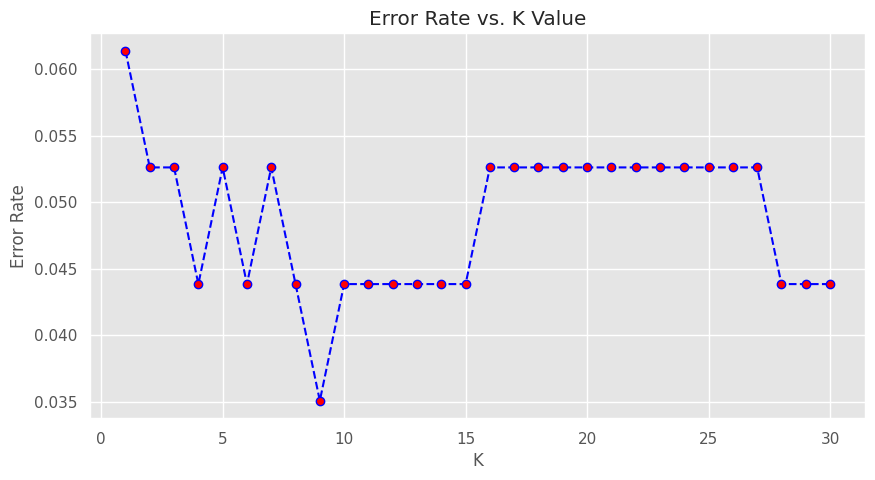

In [5]:
error_rate = []

for i in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 31), error_rate, color='blue', linestyle='--', marker='o', markerfacecolor='red')
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

## 5. Final Model Training and Evaluation

Results for KNN (K=9):
------------------------------
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



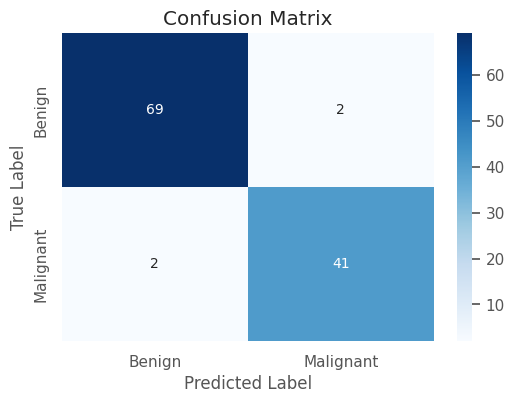

In [6]:
# Choosing optimal K based on the chart above (e.g., K=11)
optimal_k = 9
knn_final = KNeighborsClassifier(n_neighbors=optimal_k)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

# Performance metrics
print(f"Results for KNN (K={optimal_k}):")
print("-"*30)
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()